In [ ]:
# ============================================================
# INSTALL PACKAGES (Run once)
# ============================================================

!pip install --quiet gspread google-auth-oauthlib openpyxl pulp matplotlib

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import gspread
import pulp
import matplotlib.pyplot as plt
from google.colab import auth
import google.auth


In [ ]:
# ============================================================
# GOOGLE AUTHENTICATION
# ============================================================

auth.authenticate_user()
creds, _ = google.auth.default()
gc = gspread.authorize(creds)

# ============================================================
# OPEN GOOGLE SHEET
# ============================================================

sheet_url = "https://docs.google.com/spreadsheets/d/18XhbXKLsZv0hTvyudB95SZXSEatBNZXl-NuiP6zZqvo/edit?usp=sharing"
spreadsheet = gc.open_by_url(sheet_url)


In [ ]:
# Step 0: Install required packages
!pip install --quiet gspread google-auth-oauthlib

# Step 1: Import libraries
import gspread
from google.colab import auth
from google.auth import default

# Step 2: Authenticate
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Step 3: Open your spreadsheet
SPREADSHEET_URL = "https://docs.google.com/spreadsheets/d/18XhbXKLsZv0hTvyudB95SZXSEatBNZXl-NuiP6zZqvo/edit?usp=sharing"
sh = gc.open_by_url(SPREADSHEET_URL)

# Step 4: Preview sheets
all_sheets = sh.worksheets()
print("All sheets in the spreadsheet:")
for idx, sheet in enumerate(all_sheets, start=1):
    print(f"{idx}. {sheet.title}")

# Keep the first 5 sheets
sheets_to_keep = all_sheets[:5]
sheets_to_delete = [sheet for sheet in all_sheets if sheet not in sheets_to_keep]

print("\nSheets that will be deleted:")
for sheet in sheets_to_delete:
    print(sheet.title)

# Step 5: Delete sheets
for sheet in sheets_to_delete:
    print(f"Deleting sheet: {sheet.title}")
    sh.del_worksheet(sheet)

print("\nDeletion complete! Only the first 5 sheets remain.")




All sheets in the spreadsheet:
1. Privet data
2. Budget
3. Slope Values
4. Distance Values
5. K_ij_Matrix_10x10
6. neighbor_influence_t0
7. H_function_t0
8. new_population_t0
9. selected_cells_t0
10. after_treatment_t0
11. neighbor_influence_t1
12. H_function_t1
13. new_population_t1
14. selected_cells_t1
15. after_treatment_t1
16. neighbor_influence_t2
17. H_function_t2
18. new_population_t2
19. selected_cells_t2
20. after_treatment_t2

Sheets that will be deleted:
neighbor_influence_t0
H_function_t0
new_population_t0
selected_cells_t0
after_treatment_t0
neighbor_influence_t1
H_function_t1
new_population_t1
selected_cells_t1
after_treatment_t1
neighbor_influence_t2
H_function_t2
new_population_t2
selected_cells_t2
after_treatment_t2
Deleting sheet: neighbor_influence_t0
Deleting sheet: H_function_t0
Deleting sheet: new_population_t0
Deleting sheet: selected_cells_t0
Deleting sheet: after_treatment_t0
Deleting sheet: neighbor_influence_t1
Deleting sheet: H_function_t1
Deleting sheet: n

In [ ]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================




# ============================================================
# READ 2D SHEET
# ============================================================

def read_sheet_2d(sheet_name):
    ws = spreadsheet.worksheet(sheet_name)
    values = ws.get_all_values()
    return pd.DataFrame(values).astype(float).to_numpy()


# ============================================================
# READ 1D SHEET (Flatten)
# ============================================================

def read_sheet_1d(sheet_name):
    ws = spreadsheet.worksheet(sheet_name)
    values = ws.get_all_values()
    return [float(cell) for row in values for cell in row]


# ============================================================
# WRITE 2D SHEET
# ============================================================

def write_sheet(sheet_name, data_2d):
    try:
        spreadsheet.del_worksheet(spreadsheet.worksheet(sheet_name))
    except:
        pass

    rows, cols = len(data_2d), len(data_2d[0])
    ws_new = spreadsheet.add_worksheet(title=sheet_name,
                                       rows=rows,
                                       cols=cols)
    ws_new.update(data_2d)


In [ ]:
# =========================================================
# Logistic Carrying Capacity Estimation (10x10 Grid)
# EXACT REPRODUCTION VERSION
# =========================================================

# =========================================================
# READ DATA USING YOUR EXISTING HELPERS
# =========================================================

df_density = read_sheet_2d("Privet data")
df_slope   = read_sheet_2d("Slope Values")
df_dist    = read_sheet_2d("Distance Values")

grid_shape = df_density.shape   # (10,10)

density = df_density.flatten()
slope   = df_slope.flatten()
dist    = df_dist.flatten()

print("Density shape :", df_density.shape)
print("Slope shape   :", df_slope.shape)
print("Distance shape:", df_dist.shape)

# =========================================================
# REMOVE NoData (-9999)
# =========================================================

valid_mask = density != -9999

density = density[valid_mask]
slope   = slope[valid_mask]
dist    = dist[valid_mask]

# =========================================================
# CREATE DATAFRAME
# =========================================================

data = pd.DataFrame({
    "Plant_Density": density,
    "Slope": slope,
    "Dist": dist
})

# =========================================================
# LOGISTIC TRANSFORMATION (IDENTICAL TO OLD CODE)
# =========================================================

K_max = 1.0

K_frac = data["Plant_Density"] / K_max
K_frac = np.clip(K_frac, 1e-3, 1 - 1e-3)   # IMPORTANT

data["logit_K"] = np.log(K_frac / (1 - K_frac))

# =========================================================
# STANDARDIZATION (NUMPY VERSION — ddof=0)
# =========================================================

def standardize(x):
    return (x - np.mean(x)) / np.std(x)

data["Slope_std"] = standardize(data["Slope"])
data["Dist_std"]  = standardize(data["Dist"])

# =========================================================
# FIT LINEAR REGRESSION
# =========================================================

import statsmodels.api as sm

X = data[["Slope_std", "Dist_std"]]
X = sm.add_constant(X)

Y = data["logit_K"]

model = sm.OLS(Y, X)
result = model.fit()

print("\nEstimated coefficients for K_ij logistic model:\n")
print(f"β0 (Intercept) : {result.params['const']:.6f}")
print(f"β1 (Slope)     : {result.params['Slope_std']:.6f}")
print(f"β2 (Distance)  : {result.params['Dist_std']:.6f}")

# =========================================================
# COMPUTE K_ij
# =========================================================

beta_0 = result.params["const"]
beta_1 = result.params["Slope_std"]
beta_2 = result.params["Dist_std"]

data["K_ij"] = K_max / (
    1 + np.exp(
        - (beta_0
           + beta_1 * data["Slope_std"]
           + beta_2 * data["Dist_std"])
    )
)

# =========================================================
# RESHAPE BACK TO 10x10 GRID
# =========================================================

K_ij_matrix = data["K_ij"].to_numpy().reshape(grid_shape)

# =========================================================
# WRITE TO GOOGLE SHEET USING YOUR HELPER
# =========================================================

write_sheet("K_ij_Matrix_10x10", K_ij_matrix.tolist())

print("\n✅ K_ij matrix successfully written to Google Sheet.")


Density shape : (10, 10)
Slope shape   : (10, 10)
Distance shape: (10, 10)

Estimated coefficients for K_ij logistic model:

β0 (Intercept) : -5.663539
β1 (Slope)     : 0.502851
β2 (Distance)  : -1.541939

✅ K_ij matrix successfully written to Google Sheet.


In [ ]:
# ============================================================
# MATHEMATICAL FUNCTIONS
# ============================================================





# ============================================================
# NEIGHBOR INFLUENCE FUNCTION
# ============================================================

def compute_neighbor_influence(grid, lamda, mu):
    rows, cols = grid.shape
    output = np.zeros_like(grid)

    directions = [(-1,-1),(-1,0),(-1,1),
                  (0,-1),(0,1),
                  (1,-1),(1,0),(1,1)]

    for i in range(rows):
        for j in range(cols):
            influence = 0.0
            for di,dj in directions:
                ni,nj = i+di, j+dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    influence += (lamda + mu) * grid[ni,nj]
            output[i,j] = influence

    return output


In [ ]:
# ============================================================
# LOAD STATIC PARAMETERS
# ============================================================

lamda = 0.0488
mu = 0.1875
gamma = 0.5
alpha = 0.5  #0.5
beta = 0.5   #0.5
T = 9
B = 120               # constant budget each time step
r = 0.5               # intrinsic growth rate

# Load static sheets
K_ij = read_sheet_2d("K_ij_Matrix_10x10")

b_list = read_sheet_1d("Budget")
slope_list = read_sheet_1d("Slope Values")
dist_list = read_sheet_1d("Distance Values")


# Convert to Dictionaries

num_cells = len(b_list)
J = list(range(num_cells))

b = {j:b_list[j] for j in J}
slope = {j:slope_list[j] for j in J}
dist = {j:dist_list[j] for j in J}




TIME STEP t = 0
Available Budget (constant): 120
    epsilon         f1      f2  Used Budget  Remaining Budget
0       1.5  23.214489  1.4750         67.0              53.0
1       2.0  18.223644  1.9125         72.0              48.0
2       2.5  13.232800  2.4875         78.0              42.0
3       3.0  10.031911  2.9875         88.0              32.0
4       3.5   7.351556  3.4625         97.0              23.0
5       4.0   5.041067  4.0000        111.0               9.0
6       4.5   2.940622  4.5000        110.0              10.0
7       5.0   1.680356  4.8875        120.0               0.0
8       5.5   1.680356  4.8875        120.0               0.0
9       6.0   1.680356  4.8875        120.0               0.0
10      6.5   1.680356  4.8875        120.0               0.0
11      7.0   1.680356  4.8875        120.0               0.0
12      7.5   1.680356  4.8875        120.0               0.0


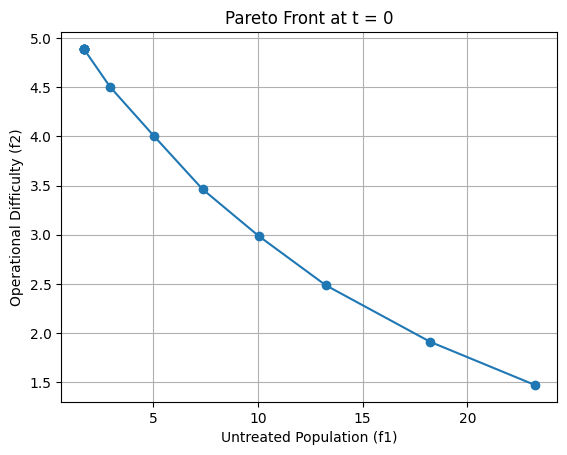


TIME STEP t = 1
Available Budget (constant): 120
    epsilon         f1      f2  Used Budget  Remaining Budget
0       1.5  11.037321  1.4375         20.0             100.0
1       2.0   8.055806  1.9875         30.0              90.0
2       2.5   5.928229  2.3875         37.0              83.0
3       3.0   3.784170  2.9750         47.0              73.0
4       3.5   2.285690  3.4125         53.0              67.0
5       4.0   1.579868  4.0000         76.0              44.0
6       4.5   1.163458  4.5000         82.0              38.0
7       5.0   0.923605  4.9750        116.0               4.0
8       5.5   0.679338  5.4875         97.0              23.0
9       6.0   0.468045  5.9750        101.0              19.0
10      6.5   0.386909  6.4750        110.0              10.0
11      7.0   0.313002  7.0000        119.0               1.0
12      7.5   0.291839  7.2125        120.0               0.0
13      8.0   0.284884  7.5500        120.0               0.0
14      8.5   0.2848

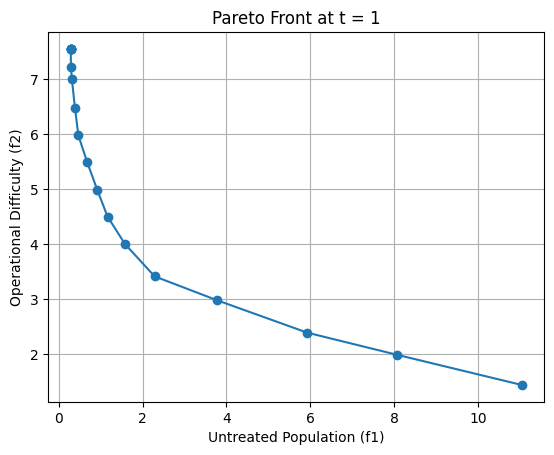


TIME STEP t = 2
Available Budget (constant): 120
    epsilon        f1      f2  Used Budget  Remaining Budget
0       1.5  4.309895  1.5000         25.0              95.0
1       2.0  2.779469  1.9750         33.0              87.0
2       2.5  2.054303  2.4250         54.0              66.0
3       3.0  1.778016  2.9750         61.0              59.0
4       3.5  1.365320  3.5000         68.0              52.0
5       4.0  1.115363  3.9750         78.0              42.0
6       4.5  0.891349  4.5000        108.0              12.0
7       5.0  0.758793  5.0000        114.0               6.0
8       5.5  0.639098  5.4625         99.0              21.0
9       6.0  0.521679  5.9875        109.0              11.0
10      6.5  0.423475  6.4750        120.0               0.0
11      7.0  0.394789  6.9750        120.0               0.0
12      7.5  0.392810  7.1375        120.0               0.0
13      8.0  0.392810  7.1375        120.0               0.0
14      8.5  0.392810  7.1375      

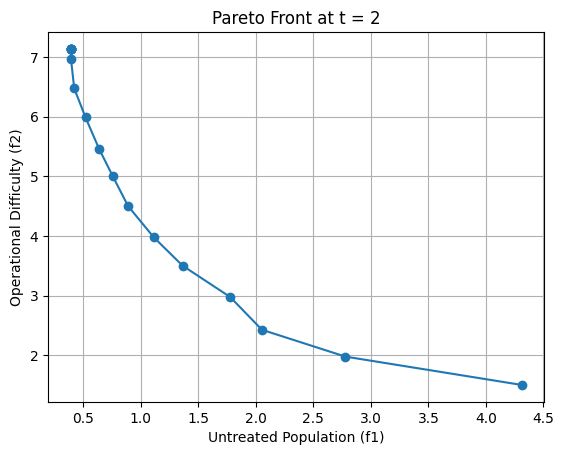


TIME STEP t = 3
Available Budget (constant): 120
    epsilon        f1      f2  Used Budget  Remaining Budget
0       1.5  2.178346  1.4750         33.0              87.0
1       2.0  1.767502  2.0000         43.0              77.0
2       2.5  1.504667  2.4750         53.0              67.0
3       3.0  1.276944  3.0000         59.0              61.0
4       3.5  1.104208  3.5000         65.0              55.0
5       4.0  0.948197  3.9625         74.0              46.0
6       4.5  0.793962  4.4875         88.0              32.0
7       5.0  0.656377  4.9750         99.0              21.0
8       5.5  0.507119  5.5000        117.0               3.0
9       6.0  0.414042  6.0000        119.0               1.0
10      6.5  0.361028  6.3125        120.0               0.0
11      7.0  0.353755  6.7250        120.0               0.0
12      7.5  0.353755  6.7250        120.0               0.0
13      8.0  0.353755  6.7250        120.0               0.0
14      8.5  0.353755  6.7250      

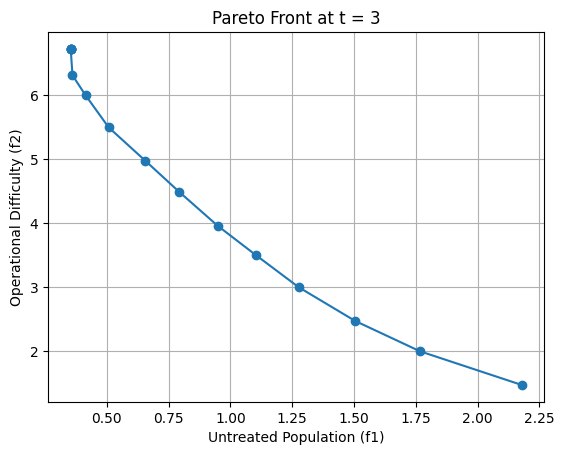


TIME STEP t = 4
Available Budget (constant): 120
    epsilon        f1      f2  Used Budget  Remaining Budget
0       2.5  1.270227  2.4875         41.0              79.0
1       3.0  1.100220  2.9750         53.0              67.0
2       3.5  0.914861  3.5000         91.0              29.0
3       4.0  0.753517  3.9875        108.0              12.0
4       4.5  0.588728  4.4500        112.0               8.0
5       5.0  0.449075  4.9375        120.0               0.0
6       5.5  0.349370  5.5000        114.0               6.0
7       6.0  0.270197  5.9625        120.0               0.0
8       6.5  0.250303  6.3750        120.0               0.0
9       7.0  0.250048  6.5500        120.0               0.0
10      7.5  0.250048  6.5500        120.0               0.0
11      8.0  0.250048  6.5500        120.0               0.0


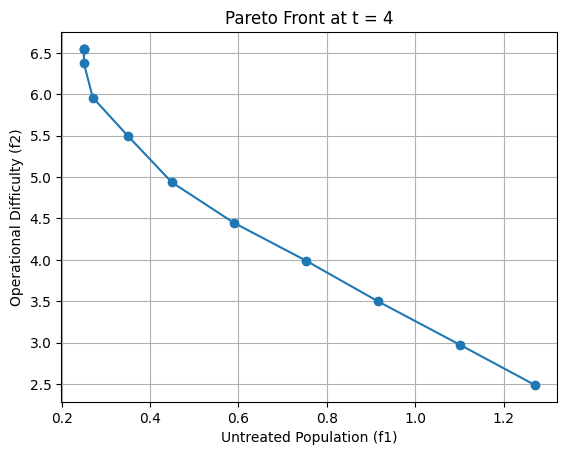


TIME STEP t = 5
Available Budget (constant): 120
   epsilon        f1      f2  Used Budget  Remaining Budget
0      2.5  0.667821  2.4875        105.0              15.0
1      3.0  0.515900  2.9750        114.0               6.0
2      3.5  0.395818  3.4375        119.0               1.0
3      4.0  0.289800  4.0000        119.0               1.0
4      4.5  0.230566  4.3875        118.0               2.0
5      5.0  0.185721  4.9750        118.0               2.0
6      5.5  0.185721  4.9750        118.0               2.0
7      6.0  0.179662  5.6125        120.0               0.0
8      6.5  0.179662  5.6125        120.0               0.0
9      7.0  0.179662  5.6125        120.0               0.0


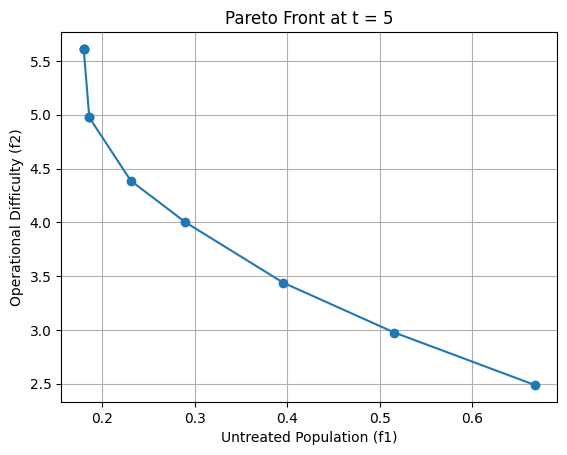


TIME STEP t = 6
Available Budget (constant): 120
   epsilon        f1      f2  Used Budget  Remaining Budget
0      2.0  0.428353  1.9000         40.0              80.0
1      2.5  0.315127  2.4625         52.0              68.0
2      3.0  0.260166  2.8875         59.0              61.0
3      3.5  0.186580  3.4875         75.0              45.0
4      4.0  0.142190  3.9000         76.0              44.0
5      4.5  0.096311  4.5000         90.0              30.0
6      5.0  0.070177  4.9875        107.0              13.0
7      5.5  0.046317  5.4750        118.0               2.0
8      6.0  0.028982  5.7250        120.0               0.0
9      6.5  0.028982  5.7250        120.0               0.0


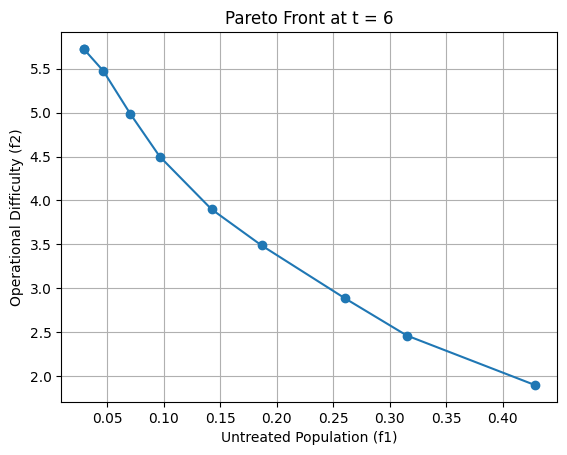


TIME STEP t = 7
Available Budget (constant): 120
   epsilon        f1      f2  Used Budget  Remaining Budget
0      2.0  0.374627  1.9750         49.0              71.0
1      2.5  0.316098  2.5000         92.0              28.0
2      3.0  0.260675  2.9500         89.0              31.0
3      3.5  0.202247  3.4750        103.0              17.0
4      4.0  0.144383  4.0000        115.0               5.0
5      4.5  0.112364  4.3875        120.0               0.0
6      5.0  0.077217  4.9875        110.0              10.0
7      5.5  0.050993  5.4125        118.0               2.0
8      6.0  0.042243  5.5875        120.0               0.0
9      6.5  0.042243  5.5875        120.0               0.0


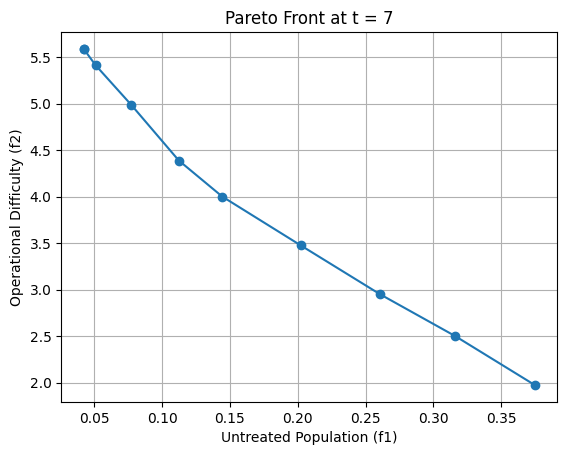


TIME STEP t = 8
Available Budget (constant): 120
   epsilon        f1      f2  Used Budget  Remaining Budget
0      2.5  0.323089  2.4250         86.0              34.0
1      3.0  0.258511  2.9750        108.0              12.0
2      3.5  0.198394  3.4375         97.0              23.0
3      4.0  0.134728  4.0000        108.0              12.0
4      4.5  0.108527  4.4250        115.0               5.0
5      5.0  0.082543  4.8500        120.0               0.0
6      5.5  0.066933  5.4500        118.0               2.0
7      6.0  0.057902  5.6250        119.0               1.0
8      6.5  0.057902  5.6250        119.0               1.0


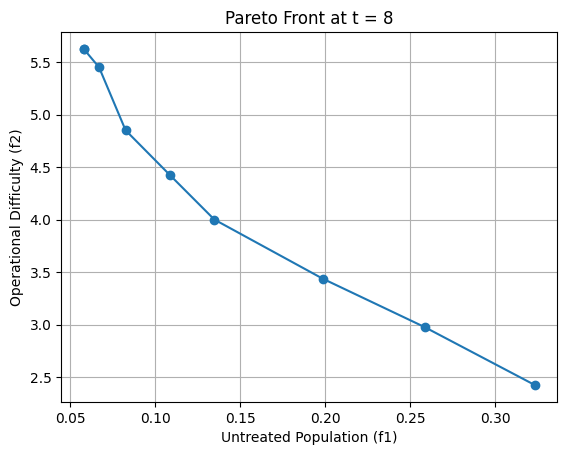

In [ ]:
# ============================================================
# DYNAMIC SIMULATION (CONSTANT BUDGET) WITH CUMULATIVE LOGISTIC UPDATE
# AND STRICT POSITIVE-POPULATION SELECTION
# ============================================================


# Read initial population grid from Google Sheet
after_treatment_prev = read_sheet_2d("Privet data")
all_pareto_results = {}

for t in range(T):
    print("\n================================================")
    print(f"TIME STEP t = {t}")
    print("Available Budget (constant):", B)
    print("================================================")

    # --------------------------------------------
    # STEP 1: Neighbor Influence
    # --------------------------------------------
    neighbor_output = compute_neighbor_influence(after_treatment_prev, lamda, mu)
    write_sheet(f"neighbor_influence_t{t}", neighbor_output.tolist())

    # --------------------------------------------
    # STEP 2: H function
    # --------------------------------------------
    h_grid = after_treatment_prev + (8/9) * neighbor_output
    write_sheet(f"H_function_t{t}", h_grid.tolist())

    # --------------------------------------------
    # STEP 3: Logistic Update
    # --------------------------------------------
    exp_rt = np.exp(r * t)  # one-step growth

    if t == 0:
        # usual logistic update for t=0
        new_a_ij = (exp_rt * K_ij * h_grid) / (K_ij + h_grid * (exp_rt - 1))
    else:
        # cumulative logistic update for t>=1
        new_a_ij = after_treatment_prev + (exp_rt * K_ij * h_grid) / (K_ij + h_grid * (exp_rt - 1))


    # Apply real-world threshold: set very small populations to zero

    threshold_value = 0.009
    new_a_ij = np.where(new_a_ij < threshold_value, 0, new_a_ij)

    # Save new population to Google Sheet
    write_sheet(f"new_population_t{t}", new_a_ij.tolist())

    # Flatten for optimization

    write_sheet(f"new_population_t{t}", new_a_ij.tolist())

    a_list = new_a_ij.flatten()
    a = {j: a_list[j] for j in J}

    # Only consider strictly positive population cells
    invaded_cells = [j for j in J if a[j] > 0]

    if not invaded_cells:
        print(f"No invaded cells remaining at t={t}. Simulation ends.")
        break

    # --------------------------------------------
    # STEP 4: Pareto Optimization via epsilon constraint
    # --------------------------------------------
    f2_max = sum(alpha * slope[j] + beta * dist[j] for j in invaded_cells)
    epsilon_values = np.arange(0, f2_max + 0.5, 0.5)

    results = []
    solutions = []

    for eps in epsilon_values:
        prob = pulp.LpProblem("Dynamic_Model", pulp.LpMinimize)
        x = pulp.LpVariable.dicts("x", J, cat="Binary")

        # Objective f1: untreated population
        prob += pulp.lpSum([a[j] * (1 - x[j]) for j in invaded_cells])

        total_population = sum(a[j] for j in invaded_cells)

        # Gamma constraint
        prob += pulp.lpSum([a[j] * x[j] for j in invaded_cells]) >= gamma * total_population

        # Constant budget
        prob += pulp.lpSum([b[j] * x[j] for j in invaded_cells]) <= B

        # Epsilon constraint
        prob += pulp.lpSum([(alpha * slope[j] + beta * dist[j]) * x[j] for j in invaded_cells]) <= eps

        # Ensure zero-population cells are never selected
        for j in J:
            if a[j] == 0:
                prob += x[j] == 0

        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        if pulp.LpStatus[prob.status] == 'Optimal':
            f1 = pulp.value(prob.objective)
            f2 = sum((alpha * slope[j] + beta * dist[j]) * (x[j].varValue or 0) for j in invaded_cells)
            used_budget = sum(b[j] * (x[j].varValue or 0) for j in invaded_cells)
            solution = {j: (x[j].varValue or 0) for j in J}

            results.append({
                'epsilon': eps,
                'f1': f1,
                'f2': f2,
                'Used Budget': used_budget,
                'Remaining Budget': B - used_budget
            })
            solutions.append(solution)

    results_df = pd.DataFrame(results)
    all_pareto_results[t] = results_df.copy()

    if results_df.empty:
        print(f"No feasible solutions at t={t}.")
        break

    # --------------------------------------------
    # PRINT & PLOT PARETO FRONT
    # --------------------------------------------
    print(results_df)
    plt.figure()
    plt.plot(results_df['f1'], results_df['f2'], marker='o')
    plt.xlabel("Untreated Population (f1)")
    plt.ylabel("Operational Difficulty (f2)")
    plt.title(f"Pareto Front at t = {t}")
    plt.grid(True)
    plt.show()

    # --------------------------------------------
    # Choose first solution (or your strategy)
    # --------------------------------------------
    first_sol = solutions[0]
    binary_vector = np.array([first_sol[j] for j in J])
    binary_grid = binary_vector.reshape(after_treatment_prev.shape)
    write_sheet(f"selected_cells_t{t}", binary_grid.tolist())

    # --------------------------------------------
    # Apply treatment: remove selected cells
    # --------------------------------------------
    after_treatment = np.where(binary_grid == 1, 0, new_a_ij)
    write_sheet(f"after_treatment_t{t}", after_treatment.tolist())

    # --------------------------------------------
    # Update for next iteration
    # --------------------------------------------
    after_treatment_prev = after_treatment.copy()


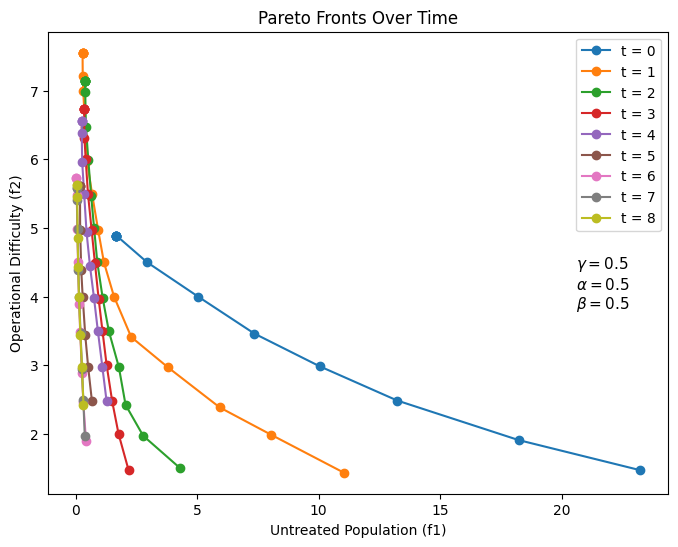

In [ ]:
# ============================================================
# PLOT ALL PARETO CURVES TOGETHER
# ============================================================

plt.figure(figsize=(8,6))

for t, df in all_pareto_results.items():
    if not df.empty:
        plt.plot(df['f1'], df['f2'],
                 marker='o',
                 label=f't = {t}')

plt.xlabel("Untreated Population (f1)")
plt.ylabel("Operational Difficulty (f2)")
plt.title("Pareto Fronts Over Time")

# Store legend in a variable
legend = plt.legend()
#plt.grid(True)

# ----------- ADD PARAMETER BOX -----------

param_text = (
    f"$\\gamma = {gamma}$\n"
    f"$\\alpha = {alpha}$\n"
    f"$\\beta = {beta}$"
)

# Draw the canvas to get correct legend position
plt.gcf().canvas.draw()

# Get legend bounding box in axis coordinates
bbox = legend.get_window_extent()
bbox = bbox.transformed(plt.gca().transAxes.inverted())

# Place text slightly below legend
plt.text(bbox.x0, bbox.y0 - 0.05,
         param_text,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top')

plt.show()



TIME STEP t = 0
Available Budget (constant): 120

--- Pareto Solution (epsilon = 0.5) ---
Selected cell indices: [21, 40, 41, 50]
Selected cell coordinates (row, col): [(2, 1), (4, 0), (4, 1), (5, 0)]

--- Pareto Solution (epsilon = 1.0) ---
Selected cell indices: [21, 31, 40, 41, 47, 50, 51, 60]
Selected cell coordinates (row, col): [(2, 1), (3, 1), (4, 0), (4, 1), (4, 7), (5, 0), (5, 1), (6, 0)]

--- Pareto Solution (epsilon = 1.5) ---
Selected cell indices: [1, 11, 12, 21, 31, 32, 40, 41, 50, 51, 60]
Selected cell coordinates (row, col): [(0, 1), (1, 1), (1, 2), (2, 1), (3, 1), (3, 2), (4, 0), (4, 1), (5, 0), (5, 1), (6, 0)]

--- Pareto Solution (epsilon = 2.0) ---
Selected cell indices: [1, 11, 12, 21, 30, 31, 32, 40, 41, 47, 50, 51, 52, 60]
Selected cell coordinates (row, col): [(0, 1), (1, 1), (1, 2), (2, 1), (3, 0), (3, 1), (3, 2), (4, 0), (4, 1), (4, 7), (5, 0), (5, 1), (5, 2), (6, 0)]

--- Pareto Solution (epsilon = 2.5) ---
Selected cell indices: [1, 2, 10, 11, 12, 21, 22, 3

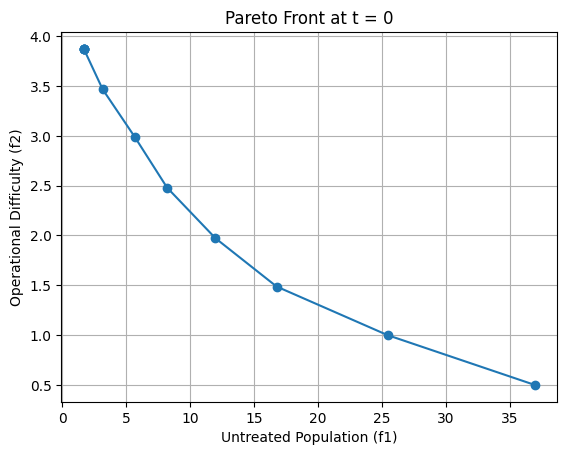


TIME STEP t = 1
Available Budget (constant): 120

--- Pareto Solution (epsilon = 0.5) ---
Selected cell indices: [31, 47, 51, 60]
Selected cell coordinates (row, col): [(3, 1), (4, 7), (5, 1), (6, 0)]

--- Pareto Solution (epsilon = 1.0) ---
Selected cell indices: [1, 11, 12, 31, 32, 51, 60]
Selected cell coordinates (row, col): [(0, 1), (1, 1), (1, 2), (3, 1), (3, 2), (5, 1), (6, 0)]

--- Pareto Solution (epsilon = 1.5) ---
Selected cell indices: [1, 11, 12, 22, 30, 31, 32, 47, 51, 60]
Selected cell coordinates (row, col): [(0, 1), (1, 1), (1, 2), (2, 2), (3, 0), (3, 1), (3, 2), (4, 7), (5, 1), (6, 0)]

--- Pareto Solution (epsilon = 2.0) ---
Selected cell indices: [1, 2, 10, 11, 12, 22, 30, 31, 32, 47, 51, 52, 60]
Selected cell coordinates (row, col): [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 2), (3, 0), (3, 1), (3, 2), (4, 7), (5, 1), (5, 2), (6, 0)]

--- Pareto Solution (epsilon = 2.5) ---
Selected cell indices: [1, 2, 10, 11, 12, 20, 22, 30, 31, 32, 47, 51, 52, 60, 70, 71]
Sel

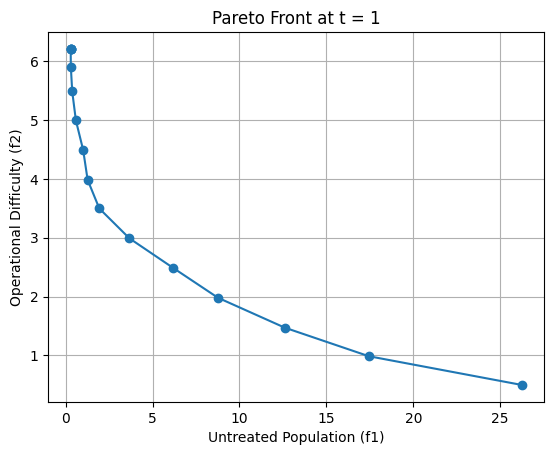


TIME STEP t = 2
Available Budget (constant): 120

--- Pareto Solution (epsilon = 0.5) ---
Selected cell indices: [1, 11, 32]
Selected cell coordinates (row, col): [(0, 1), (1, 1), (3, 2)]

--- Pareto Solution (epsilon = 1.0) ---
Selected cell indices: [1, 11, 12, 22, 30, 32]
Selected cell coordinates (row, col): [(0, 1), (1, 1), (1, 2), (2, 2), (3, 0), (3, 2)]

--- Pareto Solution (epsilon = 1.5) ---
Selected cell indices: [1, 2, 10, 11, 12, 22, 30, 32, 52]
Selected cell coordinates (row, col): [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 2), (3, 0), (3, 2), (5, 2)]

--- Pareto Solution (epsilon = 2.0) ---
Selected cell indices: [1, 2, 10, 11, 12, 20, 22, 30, 32, 52, 70, 71]
Selected cell coordinates (row, col): [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 2), (3, 0), (3, 2), (5, 2), (7, 0), (7, 1)]

--- Pareto Solution (epsilon = 2.5) ---
Selected cell indices: [1, 2, 10, 11, 12, 20, 22, 30, 32, 42, 52, 61, 71]
Selected cell coordinates (row, col): [(0, 1), (0, 2), (1, 0), (1

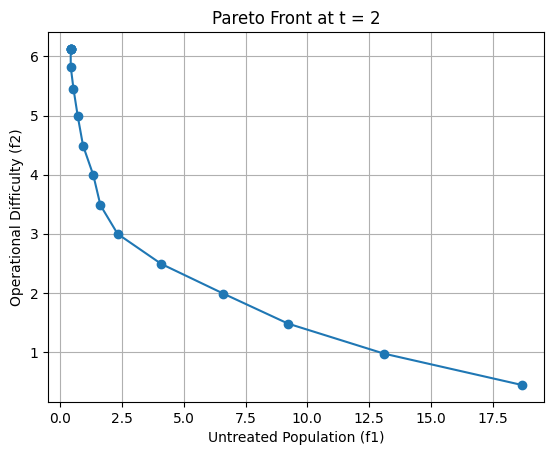

In [ ]:
# ============================================================
# DYNAMIC SIMULATION (CONSTANT BUDGET)
# WITH PRINTING OF SELECTED CELLS FOR EACH PARETO SOLUTION
# ============================================================

after_treatment_prev = read_sheet_2d("Privet data")
all_pareto_results = {}
all_selected_cells = {}

for t in range(T):
    print("\n================================================")
    print(f"TIME STEP t = {t}")
    print("Available Budget (constant):", B)
    print("================================================")

    # --------------------------------------------
    # STEP 1: Neighbor Influence
    # --------------------------------------------
    neighbor_output = compute_neighbor_influence(after_treatment_prev, lamda, mu)
    write_sheet(f"neighbor_influence_t{t}", neighbor_output.tolist())

    # --------------------------------------------
    # STEP 2: H function
    # --------------------------------------------
    h_grid = after_treatment_prev + (8/9) * neighbor_output
    write_sheet(f"H_function_t{t}", h_grid.tolist())

    # --------------------------------------------
    # STEP 3: Logistic Update
    # --------------------------------------------
    exp_rt = np.exp(r * t)

    if t == 0:
        new_a_ij = (exp_rt * K_ij * h_grid) / (K_ij + h_grid * (exp_rt - 1))
    else:
        new_a_ij = after_treatment_prev + (exp_rt * K_ij * h_grid) / (K_ij + h_grid * (exp_rt - 1))

    threshold_value = 0.009
    new_a_ij = np.where(new_a_ij < threshold_value, 0, new_a_ij)

    write_sheet(f"new_population_t{t}", new_a_ij.tolist())

    # Flatten
    a_list = new_a_ij.flatten()
    a = {j: a_list[j] for j in J}

    invaded_cells = [j for j in J if a[j] > 0]

    if not invaded_cells:
        print(f"No invaded cells remaining at t={t}. Simulation ends.")
        break

    # --------------------------------------------
    # STEP 4: Pareto Optimization
    # --------------------------------------------
    f2_max = sum(alpha * slope[j] + beta * dist[j] for j in invaded_cells)
    epsilon_values = np.arange(0, f2_max + 0.5, 0.5)

    results = []
    solutions = []
    selected_cells_per_solution = []

    for eps in epsilon_values:
        prob = pulp.LpProblem("Dynamic_Model", pulp.LpMinimize)
        x = pulp.LpVariable.dicts("x", J, cat="Binary")

        prob += pulp.lpSum([a[j] * (1 - x[j]) for j in invaded_cells])

        total_population = sum(a[j] for j in invaded_cells)

        prob += pulp.lpSum([a[j] * x[j] for j in invaded_cells]) >= gamma * total_population
        prob += pulp.lpSum([b[j] * x[j] for j in invaded_cells]) <= B
        prob += pulp.lpSum([(alpha * slope[j] + beta * dist[j]) * x[j] for j in invaded_cells]) <= eps

        for j in J:
            if a[j] == 0:
                prob += x[j] == 0

        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        if pulp.LpStatus[prob.status] == 'Optimal':

            # Extract selected indices
            selected_indices = [j for j in invaded_cells if (x[j].varValue or 0) > 0.5]

            # Convert to grid coordinates
            selected_coords = [
                (j // new_a_ij.shape[1], j % new_a_ij.shape[1])
                for j in selected_indices
            ]

            f1 = pulp.value(prob.objective)
            f2 = sum((alpha * slope[j] + beta * dist[j]) * (x[j].varValue or 0) for j in invaded_cells)
            used_budget = sum(b[j] * (x[j].varValue or 0) for j in invaded_cells)

            results.append({
                'epsilon': eps,
                'f1': f1,
                'f2': f2,
                'Used Budget': used_budget,
                'Remaining Budget': B - used_budget
            })

            solutions.append({j: (x[j].varValue or 0) for j in J})
            selected_cells_per_solution.append(selected_coords)

            # ✅ PRINT SELECTED CELLS
            print(f"\n--- Pareto Solution (epsilon = {eps}) ---")
            print("Selected cell indices:", selected_indices)
            print("Selected cell coordinates (row, col):", selected_coords)

    results_df = pd.DataFrame(results)
    all_pareto_results[t] = results_df.copy()
    all_selected_cells[t] = selected_cells_per_solution

    if results_df.empty:
        print(f"No feasible solutions at t={t}.")
        break

    # --------------------------------------------
    # PRINT & PLOT
    # --------------------------------------------
    print("\nPareto Results:")
    print(results_df)

    plt.figure()
    plt.plot(results_df['f1'], results_df['f2'], marker='o')
    plt.xlabel("Untreated Population (f1)")
    plt.ylabel("Operational Difficulty (f2)")
    plt.title(f"Pareto Front at t = {t}")
    plt.grid(True)
    plt.show()

    # --------------------------------------------
    # Choose first solution
    # --------------------------------------------
    first_sol = solutions[0]
    binary_vector = np.array([first_sol[j] for j in J])
    binary_grid = binary_vector.reshape(after_treatment_prev.shape)

    write_sheet(f"selected_cells_t{t}", binary_grid.tolist())

    # --------------------------------------------
    # Apply treatment
    # --------------------------------------------
    after_treatment = np.where(binary_grid == 1, 0, new_a_ij)
    write_sheet(f"after_treatment_t{t}", after_treatment.tolist())

    # Update
    after_treatment_prev = after_treatment.copy()